<!--Información del curso-->
<img align="left" style="padding-right:10px;" src="figuras/banner_dl.png">


<center><h1 style="font-size:2em;color:#2467C0">Proyecto: Digitalizando Números</h1></center>


# Librerias importantes

In [1]:
#pip install opencv-python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2 as cv

# Transformación de la imagen

<img src="mis_numeros/numeros.jpg" align="middle" style="width:650px;" />

In [2]:
# Realizar la transformación para un número
# mis_numeros/num_?.jpg


for i in range(10):
    img = cv.imread(f'./mis_numeros./num_{i}.jpeg')
    img_g = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_Ga = cv.GaussianBlur(img_g, (5,5), 0)
    img_r = cv.resize(img_Ga, (28,28), interpolation=cv.INTER_NEAREST)
    _, img_f = cv.threshold(img_r, 100,255,cv.THRESH_BINARY)

In [3]:
img = cv.imread(f'./mis_numeros./num_1.jpeg')
img_g = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_Ga = cv.GaussianBlur(img_g, (5,5), 0)
img_r = cv.resize(img_Ga, (28,28), interpolation=cv.INTER_NEAREST)
_, img_f = cv.threshold(img_r, 140,255,cv.THRESH_BINARY_INV)

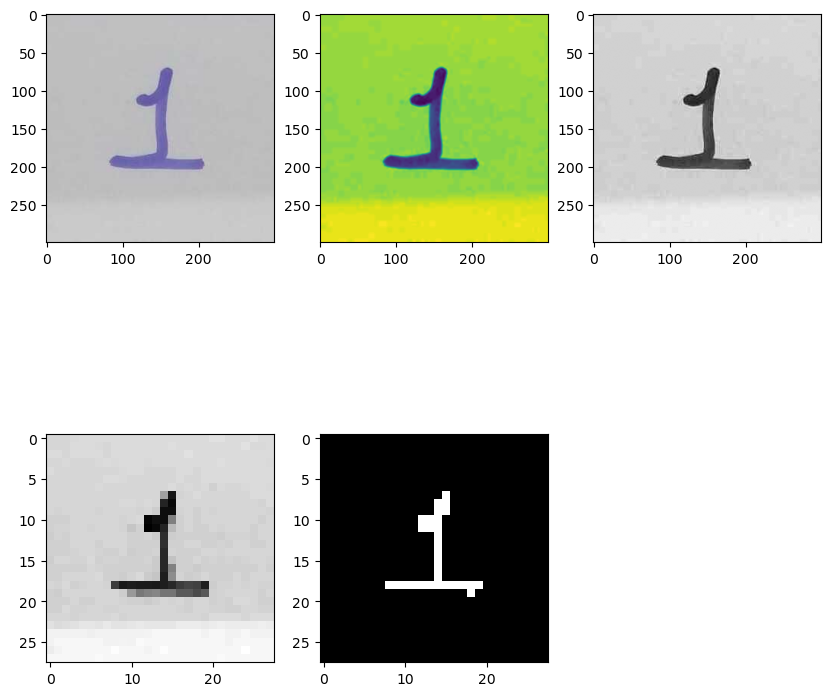

In [4]:
plt.figure(figsize=(10,10))
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.subplot(2, 3, 2)
plt.imshow(img_Ga)
plt.subplot(2, 3, 3)
plt.imshow(img_g, cmap = "gray")
plt.subplot(2, 3, 4)
plt.imshow(img_r, cmap = "gray")
plt.subplot(2, 3, 5)
plt.imshow(img_f, cmap = "gray")
plt.show()


# Arreglo de numpy

In [5]:
# Mostrar los números del arreglo sobre la imagen

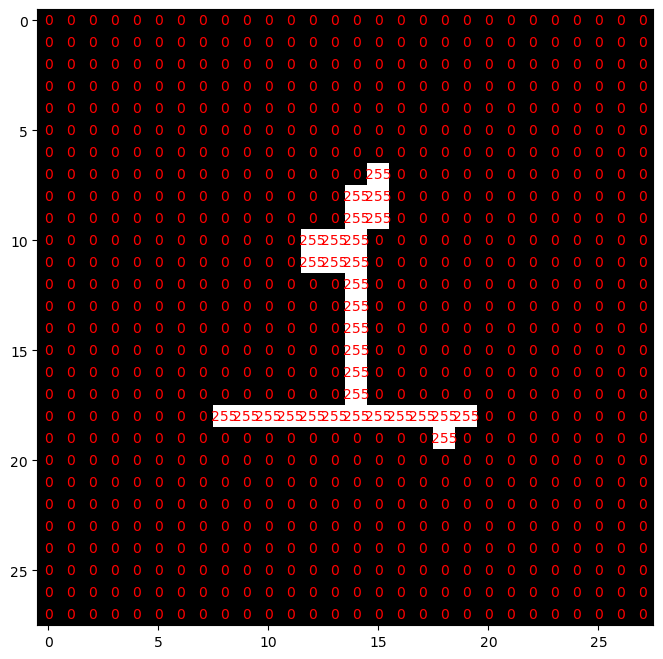

In [6]:
plt.figure(figsize= (8, 8))
plt.imshow(img_f, cmap = "gray")

for (j, i), label in np.ndenumerate(img_f):
    plt.text(i, j, label, ha = "center", va = "center", color = "red")
plt.show()
            

# DataFrame de pandas

In [7]:
#Creamos uns función para transformar la imagen
def digits(img):
    img_g = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_Ga = cv.GaussianBlur(img_g, (5,5), 0)
    img_r = cv.resize(img_Ga, (28,28), interpolation=cv.INTER_NEAREST)
    _, img_f = cv.threshold(img_r, 160,255,cv.THRESH_BINARY_INV)
    return(img_f)

0


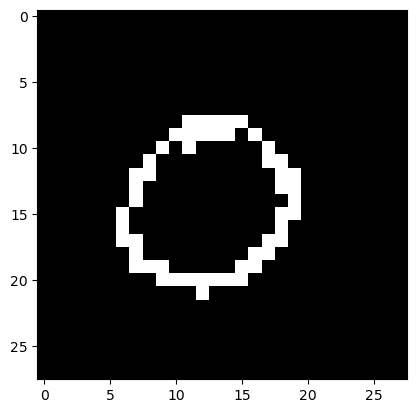

1


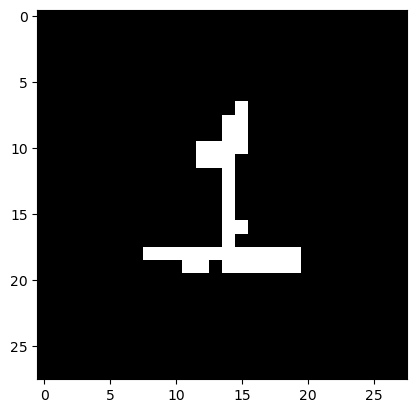

2


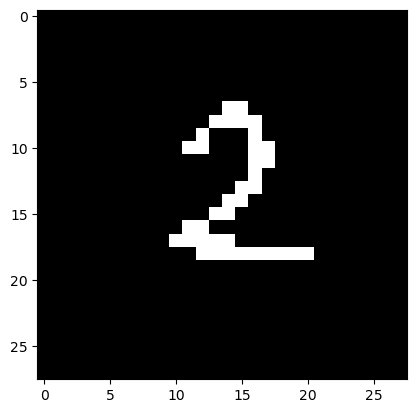

3


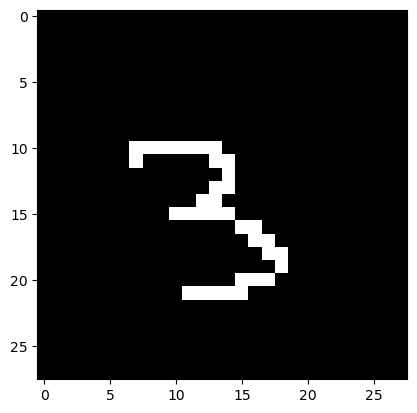

4


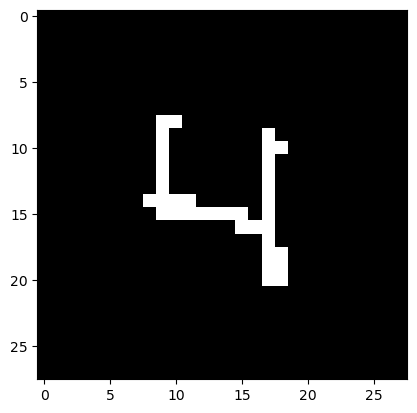

5


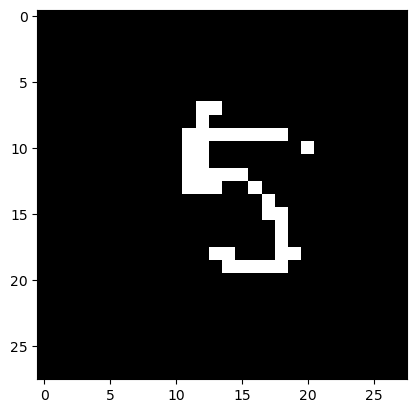

6


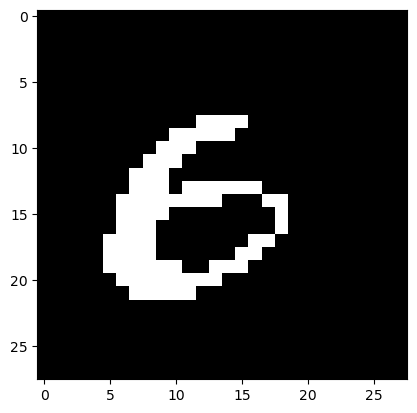

7


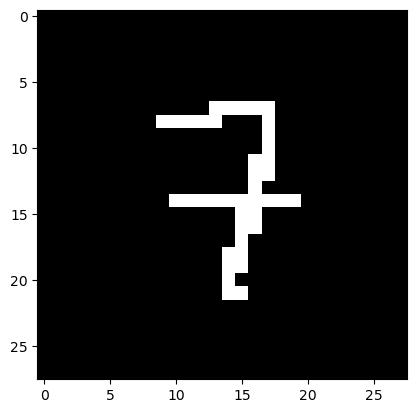

8


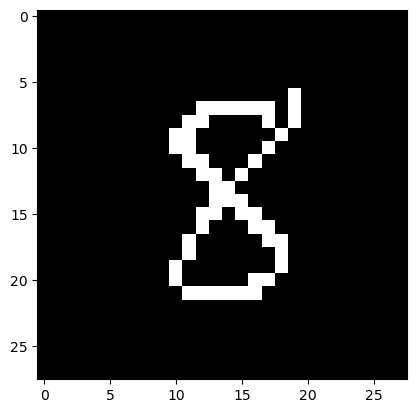

9


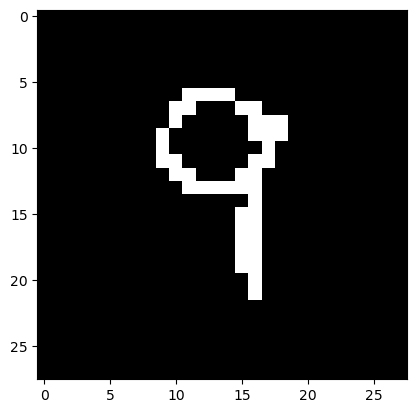

In [8]:
#Crear el DataFrame
#Creación de DataFrame
from glob import glob
contador = 0
filas=[] # Lista para almacenar las filas

df = pd.DataFrame()

for fn in glob("mis_numeros/num_*.jpeg"):
    print(contador)
    img_f = digits(cv.imread(fn))
    plt.imshow(img_f, cmap = "gray")
    plt.show()
    fila = np.append(contador, img_f.flatten())
    fila = fila.reshape(1, 785)
    filas.append(fila)
    contador = contador +1
df = pd.DataFrame(np.vstack(filas), columns=range(785))



In [9]:
df

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Exportar a un archivo CSV

In [10]:
#Exportar a un archivo csv en el directorio datos/

In [11]:
df.to_csv("datos/mis_numeros_Carlos_Chavarria.csv", header= False, index = False)